# Exploratory Data Analysis (EDA) of JZ0 and Signal Calorimeter Data 
## *By Saad Askander*

## 1. Introduction
We have 4 different types of events:
* JZ0 events: These are approximations of the full 40 MHz event rate at LHC.
* Gluon-gluon fusion (ggF) Higgs production events 
* Vector Boson fusion (VBF) Higgs production events
* Higgs-strahlung events (HS)


The calorimeter image of each event has 6 layers, each of dimensions 50 x 64 in $\eta$-$\phi$. This means we have 3200 trigger towers per layer; with each trigger tower having the dimensions 0.1 x 0.1. In total there are 19200 trigger towers per image.

These images inform us of 3 variabes: energy (GeV) and $\eta$ and $\phi$ positions of energy deposits.

We take a sample of 1000 events for each type of event for EDA.






In [ ]:
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [50]:
# Loading JZ0 events
jz0 = ak.from_parquet("/home/xzcapask/ad_trigger_data/JZ0_no_filter.parquet", columns = "cell_towers", row_groups=range(1))
jz0 = ak.to_numpy(jz0.cell_towers)

In [51]:
# Loading ggF_SM_HH4b events
ggf_sm_hh4b = ak.from_parquet("/home/xzcapask/ad_trigger_data/ggF_SM_HH4b.parquet", columns = "cell_towers", row_groups=range(1))
ggf_sm_hh4b= ak.to_numpy(ggf_sm_hh4b.cell_towers)

In [52]:
# Loading HZ_BBvv events
hz_bbvv = ak.from_parquet("/home/xzcapask/ad_trigger_data/HZ_bbvv.parquet", columns = "cell_towers", row_groups=range(1))
hz_bbvv = ak.to_numpy(hz_bbvv.cell_towers)

In [53]:
# Loading VBF_SM_HH4b events
vbf_sm_hh4b = ak.from_parquet("/home/xzcapask/ad_trigger_data/VBF_SM_HH4b.parquet", columns = "cell_towers", row_groups=range(1))
vbf_sm_hh4b = ak.to_numpy(vbf_sm_hh4b.cell_towers)

## 1. Energy Distributions

In [1]:
event_energies = pd.DataFrame(data = ggf_sm_hh4b.flatten(), columns = ["ggF"])
event_energies["vbf"] =  vbf_sm_hh4b.flatten()
event_energies["hs"] = hz_bbvv.flatten() # Higgs - Strahlung
event_energies['jz0'] = jz0.flatten()
event_energies.describe()

NameError: name 'pd' is not defined

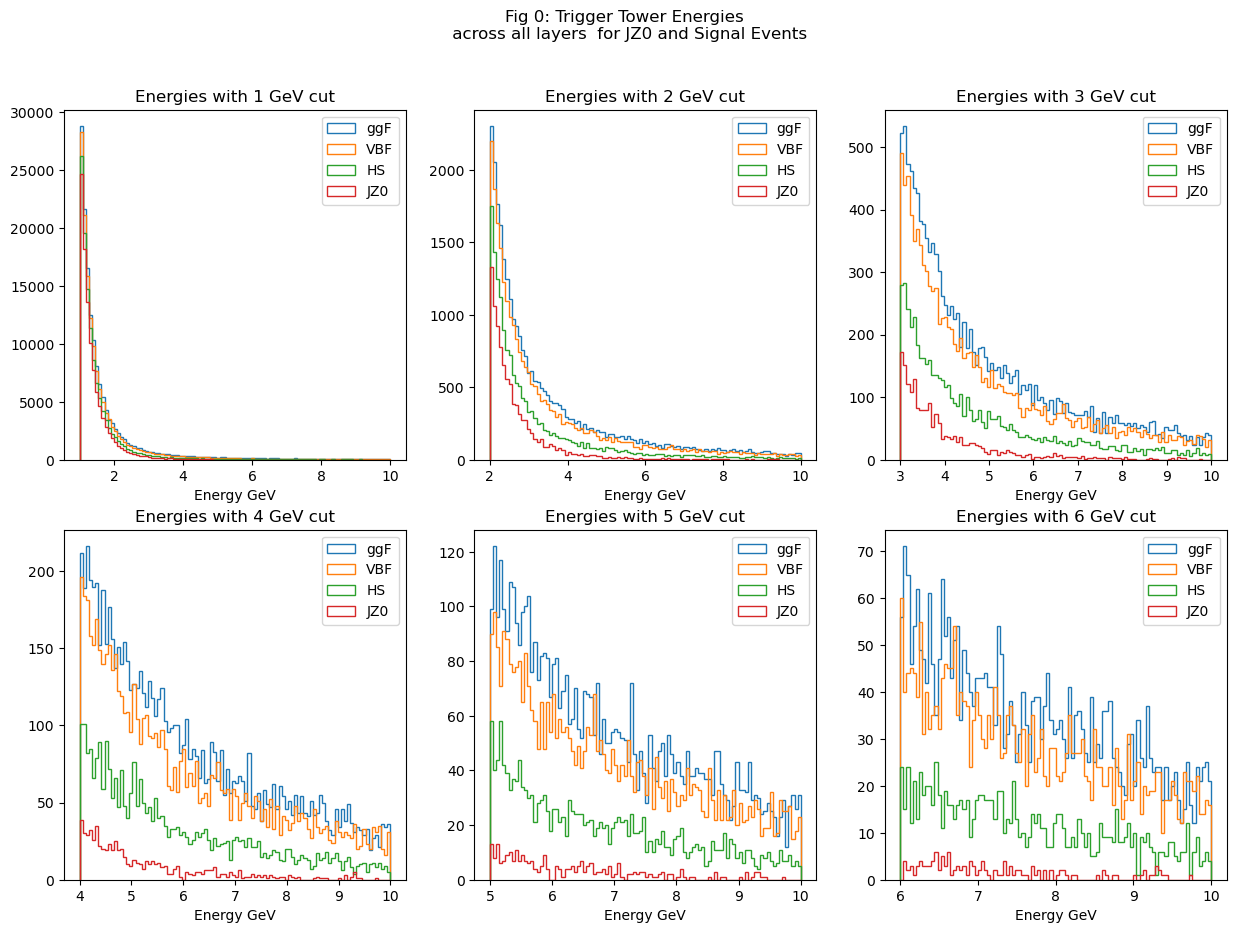

In [128]:
fig0,ax0 = plt.subplots(2,3)
fig0.set_figwidth(15)
fig0.set_figheight(10)
for i in range(0,6):
    ax0[int(i/3), i % 3].hist(event_energies['ggF'], bins = 100, range = (i + 1,10), label = "ggF", histtype = "step")
    ax0[int(i/3), i % 3].hist(event_energies['vbf'], bins = 100, range = (i + 1,10), label = "VBF", histtype = "step" )
    ax0[int(i/3), i % 3].hist(event_energies['hs'], bins = 100, range = (i + 1,10), label = "HS", histtype = "step")
    ax0[int(i/3), i % 3].hist(event_energies['jz0'], bins = 100, range = (i + 1,10) ,label = "JZ0", histtype = "step")
    ax0[int(i/3), i % 3].set_title(f"Energies with {i + 1} GeV cut")
    ax0[int(i/3), i % 3].set_xlabel("Energy GeV")
    ax0[int(i/3), i % 3].legend()
fig0.suptitle("Fig 0: Trigger Tower Energies \n across all layers  for JZ0 and Signal Events")
fig0.savefig("fig0_all_events_all_layers")

The frequency of trigger towers decrease exponentially with increasing energy. The data is quite sparse even without pileup supression with over 75% of trigger towers having 0 GeV energy for both JZ0 and signal events. 

ggF events have the largest mean energy of $0.0677 \pm 0.4001$ GeV. VBF and HS events have mean energies of $0.0655 \pm 0.3848$ GeV and $0.0596 \pm 0.2542$ GeV respectively. JZ0 events have the lowest mean energy of $0.0559 \pm 0.1734$ GeV.

Henceforth, a rudimentary pileup suppression of 2 GeV is applied and only 'active' trigger towers (have an energy greater than 2 GeV) are considered.

In [56]:
# JZ0 Pile Up Suppression
for i in range(len(jz0)):
    image_summed = np.sum(jz0[i], axis = -1)
    image_eta, image_phi = np.where(image_summed < 2)
    for j in range(len(image_eta)):      
        jz0[i,image_eta[j], image_phi[j],:] = 0 

In [57]:
# ggF Pile Up Suppression
for i in range(len(ggf_sm_hh4b)):
    image_summed = np.sum(ggf_sm_hh4b[i], axis = -1)
    image_eta, image_phi = np.where(image_summed < 2)
    for j in range(len(image_eta)):      
        ggf_sm_hh4b[i,image_eta[j], image_phi[j],:] = 0 

In [58]:
# HZ Pile Up Suppression
for i in range(len(hz_bbvv)):
    image_summed = np.sum(hz_bbvv[i], axis = -1)
    image_eta, image_phi = np.where(image_summed < 2)
    for j in range(len(image_eta)):      
        hz_bbvv[i,image_eta[j], image_phi[j],:] = 0 

In [59]:
# VBF Pile Up Suppression
for i in range(len(vbf_sm_hh4b)):
    image_summed = np.sum(vbf_sm_hh4b[i], axis = -1)
    image_eta, image_phi = np.where(image_summed < 2)
    for j in range(len(image_eta)):      
        vbf_sm_hh4b[i,image_eta[j], image_phi[j],:] = 0 

### 1.1 JZ0 Energy Distributions in Calorimeter Layers

In [106]:
jz0_layers = pd.DataFrame(data = np.reshape(jz0, (3200000,6)), columns = ["Layer 0", "Layer 1", "Layer 2", "Layer 3", "Layer 4", "Layer 5"])

# Pileup Supression
jz0_layers[jz0_layers>0].describe()

,Layer 0,Layer 1,Layer 2,Layer 3,Layer 4,Layer 5
count,16638.000000,34457.000000,34381.000000,12860.000000,12107.000000,7468.000000
mean,0.832723,0.709501,1.207535,0.230550,1.347838,1.095859
std,0.581503,0.583538,0.916388,0.301951,0.749713,0.980189
min,0.295788,0.037274,0.099685,0.036010,0.385286,0.109609
25%,0.415911,0.269436,0.570529,0.081632,0.807166,0.542109
50%,0.621287,0.584012,1.044265,0.129046,1.150830,0.823766
75%,1.049227,1.004161,1.618231,0.246112,1.699561,1.400633
max,7.037120,15.240348,18.695475,6.480349,12.399753,23.127510


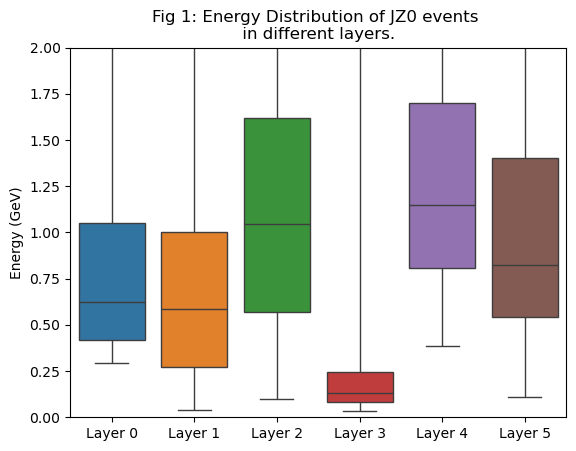

In [129]:
fig1,ax1 = plt.subplots(1,1)
sns.boxplot(data = jz0_layers[jz0_layers > 0],ax = ax1, whis = 40)
ax1.set_ylim(0,2)
ax1.set_ylabel("Energy (GeV)")
ax1.set_title("Fig 1: Energy Distribution of JZ0 events \n in different layers. ")
fig1.savefig("jz0_layers_energy.png")

 Around 69.5% of energy deposits are in the first 3 layers, with layer 3 having 49.8% of the active trigger towers and the largest median energy of 2.46 (2.18 - 2.99) GeV. A miniscule 0.007% of energy deposits are in layer 4, which has amongst the lowest median energies of 2.29 (2.14 - 2.68) GeV. The median energies increase from the first layer to the third layer. There is a drop in the 4th layer but a subseqent increase in the following layers.
 
These trends can be explained by considering the fact that the first 3 layers in the calorimeter images correspond to the ECal and the last 3 are from the Tile Calorimeter. Hence, the electrons and photons are absorbed by the first 3 layers while the hadrons continue to the latter 3 layers where they are absorbed.

In total, only 0.000498% of trigger towers are 'active' (have an energy greater than 2 GeV).

### 1.2 ggF Energy Distributions in Layers

In [108]:
ggf_layers = pd.DataFrame(data = np.reshape(ggf_sm_hh4b, (3200000,6)),columns = ["Layer 0", "Layer 1", "Layer 2", "Layer 3", "Layer 4", "Layer 5"])

# Pileup supression
ggf_layers[ggf_layers > 0].describe()

,Layer 0,Layer 1,Layer 2,Layer 3,Layer 4,Layer 5
count,27433.000000,55845.000000,56513.000000,25316.000000,23145.000000,16255.000000
mean,0.916800,1.155138,2.468361,0.374138,1.891715,1.648028
std,0.824584,2.075735,5.477929,0.736197,2.584995,2.903873
min,0.295199,0.037414,0.099596,0.036169,0.366107,0.105245
25%,0.422239,0.311400,0.694293,0.088950,0.843542,0.573793
50%,0.639471,0.686397,1.277869,0.157527,1.257435,0.938281
75%,1.113925,1.228053,2.116188,0.355146,1.980060,1.704337
max,16.991348,98.931296,221.317821,21.478768,80.293793,86.881836


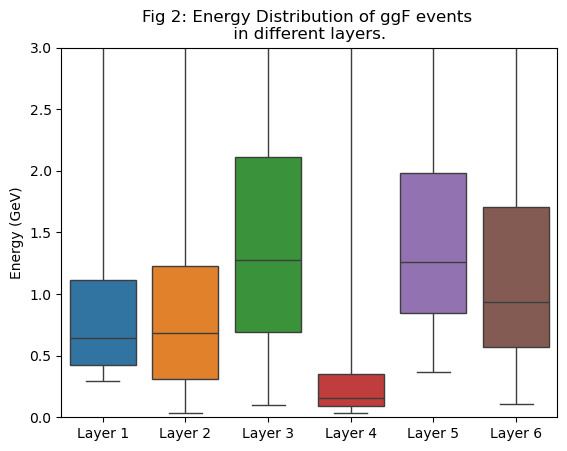

In [64]:
fig2,ax2 = plt.subplots(1,1)

sns.boxplot(data = ggf_layers[ggf_layers > 0],ax = ax2, whis = 100)
ax2.set_ylim(0,3)
ax2.set_ylabel("Energy (GeV)")
ax2.set_title("Fig 2: Energy Distribution of ggF events \n in different layers. ")
fig2.savefig("ggf_layers_energy.png")

The median energies in each layer are higher than those in JZ0 events with larger spreads. In particular, the median energy in the 3rd layer is 3.31 (2.41 - 6.19) GeV. Like JZ0 events, the median energy increases till the 3rd layer. Unlike JZ0 events, the median energy then subsequently drops till the 5th layer before increasing again for the 6th layer.

 We have 0.00173% active trigger towers across all layers, which is 4 times higher than in JZ0 events. 

### 1.3 VBF Energy Distributions in Layers

In [109]:
vbf_layers = pd.DataFrame(data = np.reshape(vbf_sm_hh4b, (3200000,6)),columns = ["Layer 0", "Layer 1", "Layer 2", "Layer 3", "Layer 4", "Layer 5"])
vbf_layers[vbf_layers > 0].describe()

,Layer 0,Layer 1,Layer 2,Layer 3,Layer 4,Layer 5
count,24574.000000,51855.000000,52337.000000,23069.000000,21068.000000,14727.000000
mean,0.909950,1.073048,2.269727,0.374975,1.844092,1.543160
std,0.801753,1.921654,5.325194,0.811223,2.755726,2.813443
min,0.295529,0.037383,0.100880,0.036147,0.365467,0.106191
25%,0.419552,0.301544,0.672759,0.087937,0.839409,0.575552
50%,0.648741,0.667795,1.241545,0.155592,1.251238,0.916748
75%,1.103382,1.184038,2.035764,0.349691,1.952535,1.645884
max,17.065643,84.646276,348.895276,26.726687,103.625031,114.414993


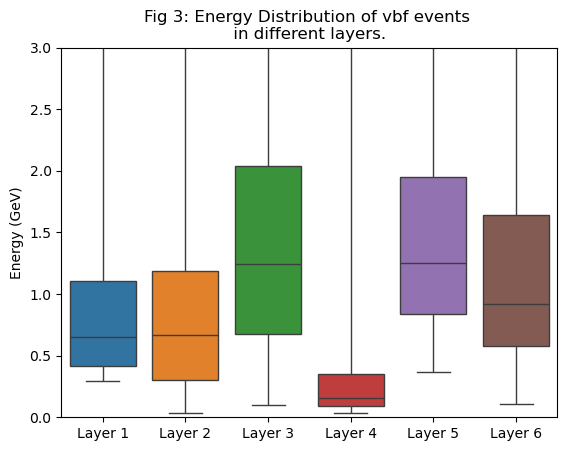

In [66]:
fig3,ax3 = plt.subplots(1,1)

sns.boxplot(data = vbf_layers[vbf_layers > 0],ax = ax3, whis = 100)
ax3.set_ylim(0,3)
ax3.set_ylabel("Energy (GeV)")
ax3.set_title("Fig 3: Energy Distribution of vbf events \n in different layers. ")
fig3.savefig("vbf_layers_energy.png")

In contrast to JZ0 and ggF events, the median energy is highest in the 2nd layer and has a value 3.17 (2.39 - 5.12) GeV. It drops from the 2nd layer to the 5th layer before increasing again in the 6th layer. 

0.00149% of the trigger towers are active which is higher than than of JZ0 events but slightly lower than ggF events.


### 1.4 HS Energy Distributions in Layers

In [67]:
hs_layers = pd.DataFrame(data = np.reshape(hz_bbvv, (3200000,6)),columns = ["Layer 0","Layer 1", "Layer 2", "Layer 3", "Layer 4", "Layer 5"])
hs_layers[hs_layers > 0].describe()

,Layer 1,Layer 2,Layer 3,Layer 4,Layer 5,Layer 6
count,20348.000000,42381.000000,42753.000000,17352.000000,15623.000000,10462.000000
mean,0.860975,0.863844,1.683545,0.292731,1.519518,1.271129
std,0.657692,1.228455,3.318774,0.541239,1.540891,1.635574
min,0.295199,0.037296,0.102475,0.036009,0.370114,0.107562
25%,0.417808,0.285919,0.619792,0.085100,0.813944,0.554268
50%,0.637578,0.621446,1.146605,0.141026,1.184445,0.868976
75%,1.084102,1.078304,1.809344,0.291967,1.779371,1.500321
max,15.329210,41.724678,223.529630,20.001253,74.510696,58.121880


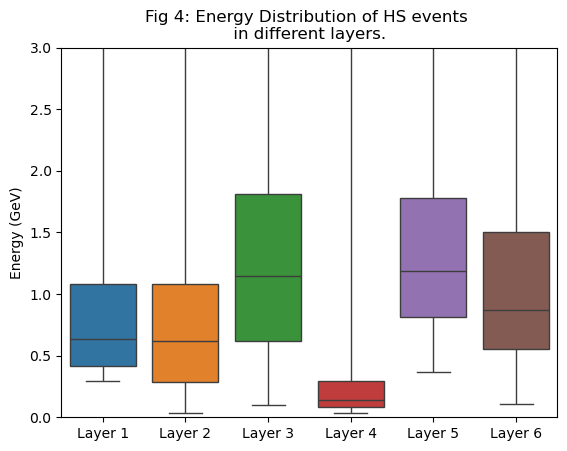

In [69]:
fig4,ax4 = plt.subplots(1,1)

sns.boxplot(data = hs_layers[hs_layers > 0],ax = ax4, whis = 100)
ax4.set_ylim(0,3)
ax4.set_ylabel("Energy (GeV)")
ax4.set_title("Fig 4: Energy Distribution of HS events \n in different layers. ")
fig4.savefig("hs_layers_energy.png")

The 2nd layer has the highest median energy of 2.77 (2.28 - 4.14) GeV. The median energies are on average smaller than that of ggF and VBF events but still higher than JZ0 events.


0.000891% of the trigger towers are active.

## 2. $\eta$ and $\phi$

In [70]:
# jz0 events
jz0_pos_info = np.where(jz0> 0)
jz0_pos = pd.DataFrame(data = jz0_pos_info[1], columns = ["eta_index"] )
jz0_pos["phi_index"] = jz0_pos_info[2]
jz0_pos["layer_index"] = jz0_pos_info[3]
jz0_pos["eta_pos"] = 2.5 - 0.1 * jz0_pos["eta_index"]
jz0_pos["phi_pos"] = - np.pi + 0.1 * jz0_pos["phi_index"]

#ggF events
ggf_pos_info = np.where(ggf_sm_hh4b> 0)
ggf_pos = pd.DataFrame(data = ggf_pos_info[1], columns = ["eta_index"] )
ggf_pos["phi_index"] = ggf_pos_info[2]
ggf_pos["layer_index"] = ggf_pos_info[3]
ggf_pos["eta_pos"] = 2.5 - 0.1 * ggf_pos["eta_index"]
ggf_pos["phi_pos"] = -np.pi + 0.1 * ggf_pos["phi_index"]

## vbf
vbf_pos_info = np.where(vbf_sm_hh4b> 0)
vbf_pos = pd.DataFrame(data = vbf_pos_info[1], columns = ["eta_index"] )
vbf_pos["phi_index"] = vbf_pos_info[2]
vbf_pos["layer_index"] = vbf_pos_info[3]
vbf_pos["eta_pos"] = 2.5 - 0.1 * vbf_pos["eta_index"]
vbf_pos["phi_pos"] = -np.pi + 0.1 * vbf_pos["phi_index"]

#hs
hs_pos_info = np.where(hz_bbvv> 0)
hs_pos = pd.DataFrame(data = hs_pos_info[1], columns = ["eta_index"] )
hs_pos["phi_index"] = hs_pos_info[2]
hs_pos["layer_index"] = hs_pos_info[3]
hs_pos["eta_pos"] = 2.5 - 0.1 * hs_pos["eta_index"]
hs_pos["phi_pos"] = - np.pi + 0.1 * hs_pos["phi_index"]


### 2.1 $\eta$

In [73]:
jz0_pos["eta_pos"].describe()

count    117911.000000
mean          0.052406
std           1.133148
min          -2.400000
25%          -0.700000
50%           0.100000
75%           0.800000
max           2.500000
Name: eta_pos, dtype: float64

In [74]:
ggf_pos["eta_pos"].describe()

count    204507.000000
mean          0.052741
std           1.118960
min          -2.400000
25%          -0.700000
50%           0.100000
75%           0.800000
max           2.500000
Name: eta_pos, dtype: float64

In [75]:
vbf_pos["eta_pos"].describe()

count    187630.000000
mean          0.066468
std           1.197584
min          -2.400000
25%          -0.800000
50%           0.100000
75%           0.900000
max           2.500000
Name: eta_pos, dtype: float64

In [76]:
hs_pos["eta_pos"].describe()

count    148919.000000
mean          0.049933
std           1.151290
min          -2.400000
25%          -0.700000
50%           0.100000
75%           0.800000
max           2.500000
Name: eta_pos, dtype: float64

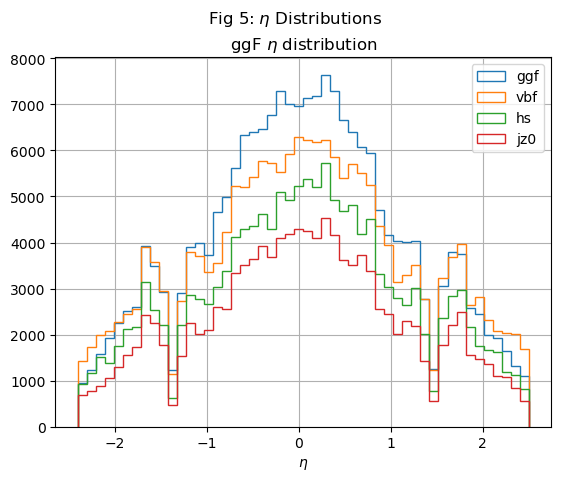

In [116]:
fig5,ax5 = plt.subplots(1,1)

fig5.suptitle("Fig 5: $\eta$ Distributions")

ax5.hist(ggf_pos["eta_pos"], bins = 50, label = "ggf", histtype = "step")
ax5.hist(vbf_pos["eta_pos"], bins = 50, label = "vbf" , histtype = "step")
ax5.hist(hs_pos["eta_pos"], bins = 50, label = "hs" , histtype = "step")
ax5.hist(jz0_pos["eta_pos"], bins = 50, label = "jz0" , histtype = "step")

ax5.legend()
ax5.set_xlabel("$\eta$")
ax5.grid(which = "both")
ax5.set_title("ggF $\eta$ distribution")
fig5.savefig("Eta Distributions.png")


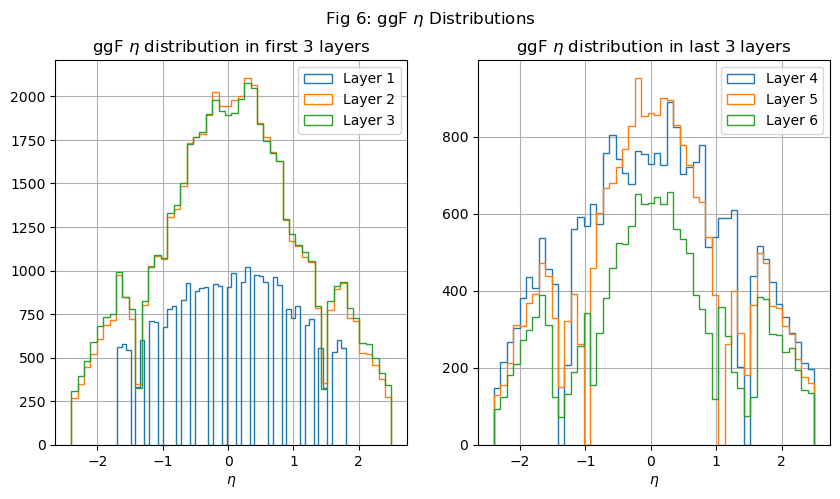

In [118]:
fig6,ax6 = plt.subplots(1,2)
fig6.set_figheight(5)
fig6.set_figwidth(10)

fig6.suptitle("Fig 6: ggF $\eta$ Distributions")


ax6[0].hist(ggf_pos[ggf_pos.layer_index == 0].eta_pos, bins = 50, label = "Layer 1", histtype = "step")
ax6[0].hist(ggf_pos[ggf_pos.layer_index == 1].eta_pos, bins = 50, label = "Layer 2", histtype = "step")
ax6[0].hist(ggf_pos[ggf_pos.layer_index == 2].eta_pos, bins = 50, label = "Layer 3", histtype = "step")

ax6[0].legend()
ax6[0].set_title("ggF $\eta$ distribution in first 3 layers")
ax6[0].set_xlabel("$\eta$")
ax6[0].grid(which = "both")

ax6[1].hist(ggf_pos[ggf_pos.layer_index == 3].eta_pos, bins = 50, label = "Layer 4", histtype = "step")
ax6[1].hist(ggf_pos[ggf_pos.layer_index == 4].eta_pos, bins = 50, label = "Layer 5", histtype = "step")
ax6[1].hist(ggf_pos[ggf_pos.layer_index == 5].eta_pos, bins = 50, label = "Layer 6", histtype = "step")
ax6[1].legend()
ax6[1].set_title("ggF $\eta$ distribution in last 3 layers")
ax6[1].set_xlabel("$\eta$")
ax6[1].grid(which = "both")

fig6.savefig("eta_distribution_jz0.png")

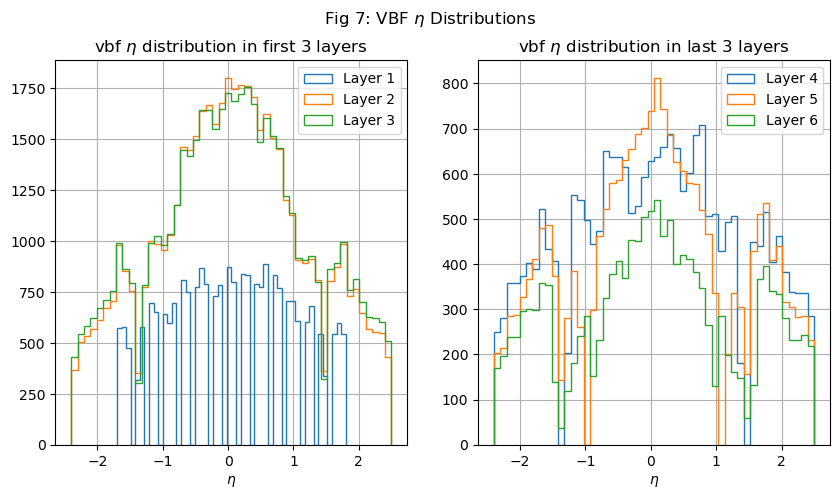

In [119]:
fig6_1,ax6_1 = plt.subplots(1,2)
fig6_1.set_figheight(5)
fig6_1.set_figwidth(10)

fig6_1.suptitle("Fig 7: VBF $\eta$ Distributions")

ax6_1[0].hist(vbf_pos[vbf_pos.layer_index == 0].eta_pos, bins = 50, label = "Layer 1", histtype = "step")
ax6_1[0].hist(vbf_pos[vbf_pos.layer_index == 1].eta_pos, bins = 50, label = "Layer 2", histtype = "step")
ax6_1[0].hist(vbf_pos[vbf_pos.layer_index == 2].eta_pos, bins = 50, label = "Layer 3", histtype = "step")
ax6_1[0].legend()
ax6_1[0].set_title("vbf $\eta$ distribution in first 3 layers")
ax6_1[0].set_xlabel("$\eta$")
ax6_1[0].grid(which = "both")


ax6_1[1].hist(vbf_pos[vbf_pos.layer_index == 3].eta_pos, bins = 50, label = "Layer 4", histtype = "step")
ax6_1[1].hist(vbf_pos[vbf_pos.layer_index == 4].eta_pos, bins = 50, label = "Layer 5", histtype = "step")
ax6_1[1].hist(vbf_pos[vbf_pos.layer_index == 5].eta_pos, bins = 50, label = "Layer 6", histtype = "step")
ax6_1[1].legend()
ax6_1[1].set_title("vbf $\eta$ distribution in last 3 layers")
ax6_1[1].set_xlabel("$\eta$")
ax6_1[1].grid(which = "both")

fig6_1.savefig("eta_distribution_vbf.png")

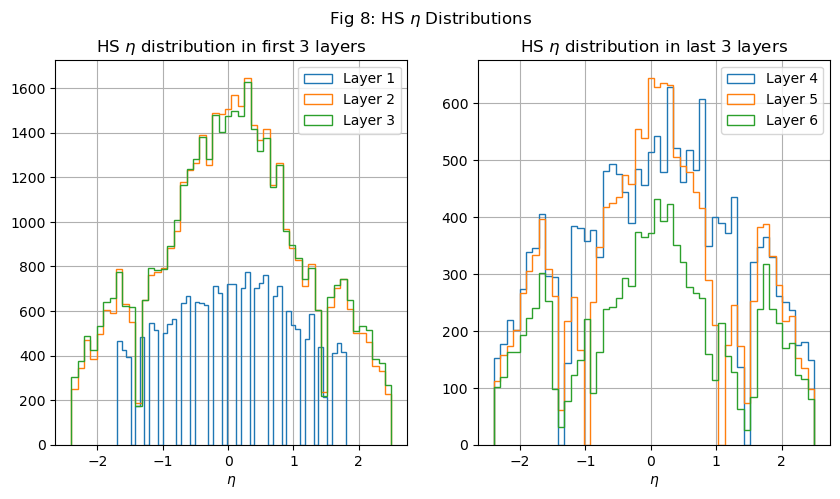

In [123]:
fig6_2,ax6_2 = plt.subplots(1,2)
fig6_2.set_figheight(5)
fig6_2.set_figwidth(10)

fig6_2.suptitle("Fig 8: HS $\eta$ Distributions")

ax6_2[0].hist(hs_pos[hs_pos.layer_index == 0].eta_pos, bins = 50, label = "Layer 1", histtype = "step")
ax6_2[0].hist(hs_pos[hs_pos.layer_index == 1].eta_pos, bins = 50, label = "Layer 2", histtype = "step")
ax6_2[0].hist(hs_pos[hs_pos.layer_index == 2].eta_pos, bins = 50, label = "Layer 3", histtype = "step")
ax6_2[0].legend()
ax6_2[0].set_title("HS $\eta$ distribution in first 3 layers")
ax6_2[0].set_xlabel("$\eta$")
ax6_2[0].grid(which = "both")


ax6_2[1].hist(hs_pos[hs_pos.layer_index == 3].eta_pos, bins = 50, label = "Layer 4", histtype = "step")
ax6_2[1].hist(hs_pos[hs_pos.layer_index == 4].eta_pos, bins = 50, label = "Layer 5", histtype = "step")
ax6_2[1].hist(hs_pos[hs_pos.layer_index == 5].eta_pos, bins = 50, label = "Layer 6", histtype = "step")

ax6_2[1].legend()
ax6_2[1].set_title("HS $\eta$ distribution in last 3 layers")
ax6_2[1].set_xlabel("$\eta$")
ax6_2[1].grid(which = "both")

fig6_2.savefig("eta_distribution_hs.png")

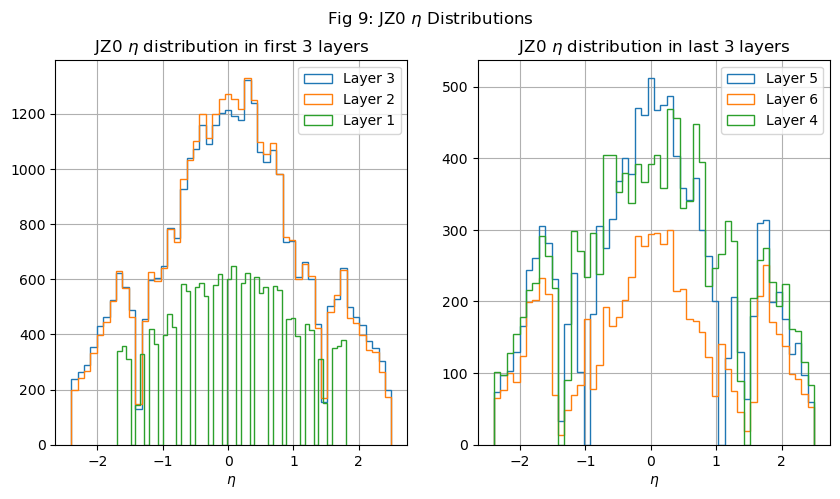

In [124]:
fig6_3,ax6_3 = plt.subplots(1,2)
fig6_3.set_figheight(5)
fig6_3.set_figwidth(10)

fig6_3.suptitle("Fig 9: JZ0 $\eta$ Distributions")

ax6_3[0].hist(jz0_pos[jz0_pos.layer_index == 2].eta_pos, bins = 50, label = "Layer 3", histtype = "step")
ax6_3[0].hist(jz0_pos[jz0_pos.layer_index == 1].eta_pos, bins = 50, label = "Layer 2", histtype = "step")
ax6_3[0].hist(jz0_pos[jz0_pos.layer_index == 0].eta_pos, bins = 50, label = "Layer 1", histtype = "step")
ax6_3[0].legend()
ax6_3[0].set_title("JZ0 $\eta$ distribution in first 3 layers")
ax6_3[0].set_xlabel("$\eta$")
ax6_3[0].grid(which = "both")

ax6_3[1].hist(jz0_pos[jz0_pos.layer_index == 4].eta_pos, bins = 50, label = "Layer 5", histtype = "step")
ax6_3[1].hist(jz0_pos[jz0_pos.layer_index == 5].eta_pos, bins = 50, label = "Layer 6", histtype = "step")
ax6_3[1].hist(jz0_pos[jz0_pos.layer_index == 3].eta_pos, bins = 50, label = "Layer 4", histtype = "step")
ax6_3[1].legend()
ax6_3[1].set_title("JZ0 $\eta$ distribution in last 3 layers")
ax6_3[1].set_xlabel("$\eta$")
ax6_3[1].grid(which = "both")

fig6_3.savefig("eta_distribution_jz0.png")

All the events have similar distributions in $\eta$. They cover all possible values of $\eta$ with 3 modes around $\eta = 0, \eta = 2, \eta = -2$.

A deeper analysis into the $\eta$ distributions in all the layers show that the trigger towers are initially evenly spread out in $\eta$. However in the 2nd and 3rd layers we see a shift towards the 3 modes around $\eta = 0, \eta = 2, \eta = -2$. The same behaviour is observed from the 4th to 6th layers. This behaviour is observed for all types of events.

### 2.2 $\phi$

In [87]:
jz0_pos["phi_pos"].describe()

count    117911.000000
mean          0.028007
std           1.847646
min          -3.141593
25%          -1.541593
50%           0.058407
75%           1.658407
max           3.158407
Name: phi_pos, dtype: float64

In [88]:
ggf_pos["phi_pos"].describe()

count    204507.000000
mean          0.016823
std           1.838432
min          -3.141593
25%          -1.541593
50%           0.058407
75%           1.558407
max           3.158407
Name: phi_pos, dtype: float64

In [89]:
vbf_pos["phi_pos"].describe()

count    187630.000000
mean          0.019539
std           1.840699
min          -3.141593
25%          -1.541593
50%           0.058407
75%           1.658407
max           3.158407
Name: phi_pos, dtype: float64

In [90]:
hs_pos["phi_pos"].describe()

count    148919.000000
mean          0.025491
std           1.838016
min          -3.141593
25%          -1.541593
50%           0.058407
75%           1.658407
max           3.158407
Name: phi_pos, dtype: float64

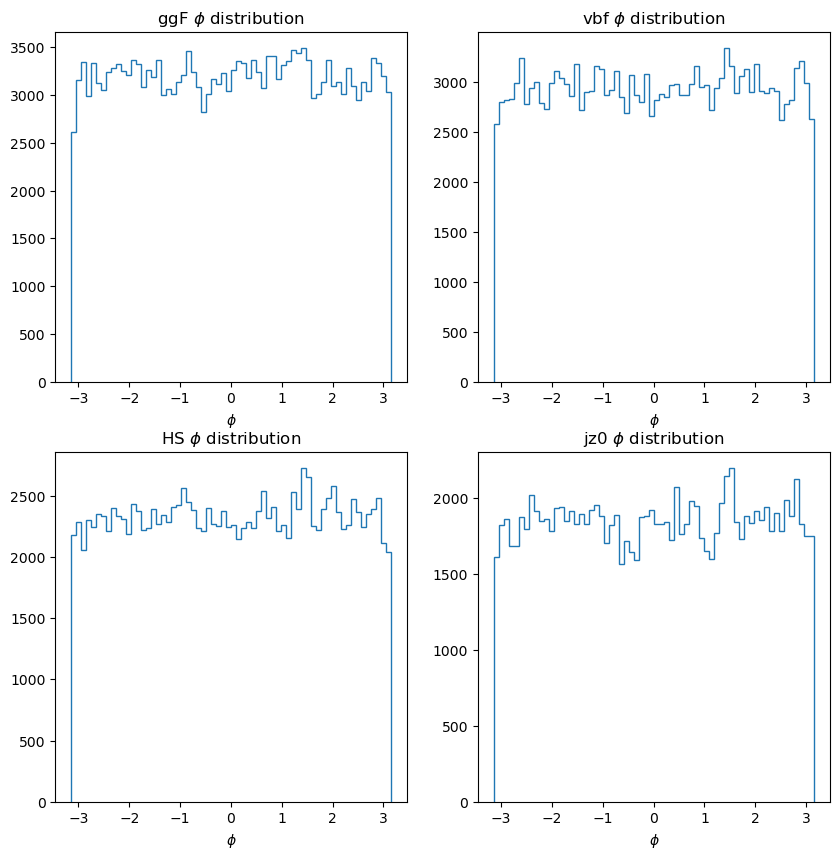

In [91]:
fig7,ax7 = plt.subplots(2,2)
fig7.set_figheight(10)
fig7.set_figwidth(10)


fig7.suptitle("Fig 10: $\phi$ Distributions")


ax7[0,0].hist(ggf_pos["phi_pos"], bins = 64, label = "ggf", histtype = "step")
ax7[0,0].set_title("ggF $\phi$ distribution")
ax7[0,0].set_xlabel("$\phi$")

ax7[0,1].hist(vbf_pos["phi_pos"], bins = 64, label = "vbf", histtype = "step")
ax7[0,1].set_title("vbf $\phi$ distribution")
ax7[0,1].set_xlabel("$\phi$")

ax7[1,0].hist(hs_pos["phi_pos"], bins = 64, label = "hs", histtype = "step")
ax7[1,0].set_title("HS $\phi$ distribution")
ax7[1,0].set_xlabel("$\phi$")

ax7[1,1].hist(jz0_pos["phi_pos"], bins = 64, label = "jz0", histtype = "step")
ax7[1,1].set_title("jz0 $\phi$ distribution")
ax7[1,1].set_xlabel("$\phi$")

fig7.savefig("phi distributions.png")

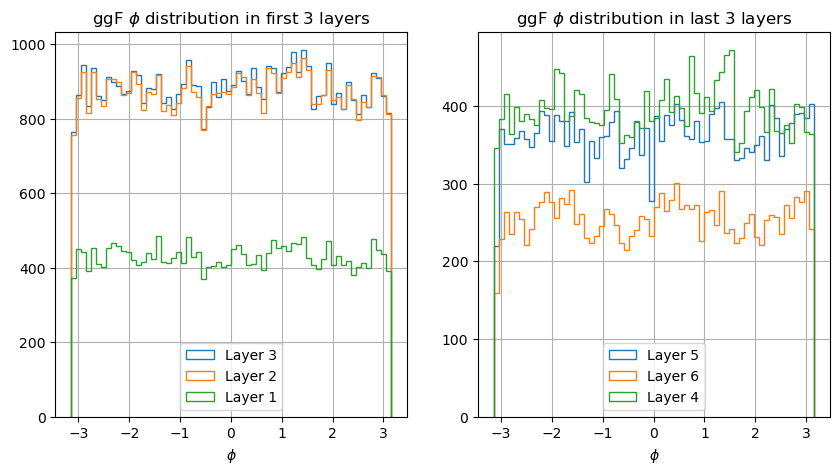

In [92]:
fig8,ax8 = plt.subplots(1,2)
fig8.set_figheight(5)
fig8.set_figwidth(10)

ax8[0].hist(ggf_pos[ggf_pos.layer_index == 2].phi_pos, bins = 64, label = "Layer 3", histtype = "step")
ax8[0].hist(ggf_pos[ggf_pos.layer_index == 1].phi_pos, bins = 64, label = "Layer 2", histtype = "step")
ax8[0].hist(ggf_pos[ggf_pos.layer_index == 0].phi_pos, bins = 64, label = "Layer 1", histtype = "step")
ax8[0].legend()
ax8[0].set_title("ggF $\phi$ distribution in first 3 layers")
ax8[0].set_xlabel("$\phi$")
ax8[0].grid(which = "both")


ax8[1].hist(ggf_pos[ggf_pos.layer_index == 4].phi_pos, bins = 64, label = "Layer 5", histtype = "step")
ax8[1].hist(ggf_pos[ggf_pos.layer_index == 5].phi_pos, bins = 64, label = "Layer 6", histtype = "step")
ax8[1].hist(ggf_pos[ggf_pos.layer_index == 3].phi_pos, bins = 64, label = "Layer 4", histtype = "step")
ax8[1].legend()
ax8[1].set_title("ggF $\phi$ distribution in last 3 layers")
ax8[1].set_xlabel("$\phi$")
ax8[1].grid(which = "both")

fig8.savefig("phi_distribution_ggf.png")

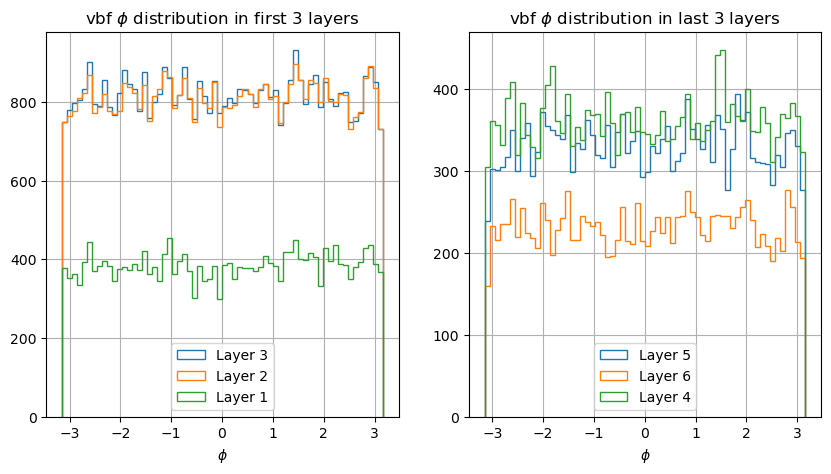

In [93]:
fig9,ax9 = plt.subplots(1,2)
fig9.set_figheight(5)
fig9.set_figwidth(10)

ax9[0].hist(vbf_pos[vbf_pos.layer_index == 2].phi_pos, bins = 64, label = "Layer 3", histtype = "step")
ax9[0].hist(vbf_pos[vbf_pos.layer_index == 1].phi_pos, bins = 64, label = "Layer 2", histtype = "step")
ax9[0].hist(vbf_pos[vbf_pos.layer_index == 0].phi_pos, bins = 64, label = "Layer 1", histtype = "step")
ax9[0].legend()
ax9[0].set_title("vbf $\phi$ distribution in first 3 layers")
ax9[0].set_xlabel("$\phi$")
ax9[0].grid(which = "both")


ax9[1].hist(vbf_pos[vbf_pos.layer_index == 4].phi_pos, bins = 64, label = "Layer 5", histtype = "step")
ax9[1].hist(vbf_pos[vbf_pos.layer_index == 5].phi_pos, bins = 64, label = "Layer 6", histtype = "step")
ax9[1].hist(vbf_pos[vbf_pos.layer_index == 3].phi_pos, bins = 64, label = "Layer 4", histtype = "step")
ax9[1].legend()
ax9[1].set_title("vbf $\phi$ distribution in last 3 layers")
ax9[1].set_xlabel("$\phi$")
ax9[1].grid(which = "both")

fig9.savefig("phi_distribution_vbf.png")

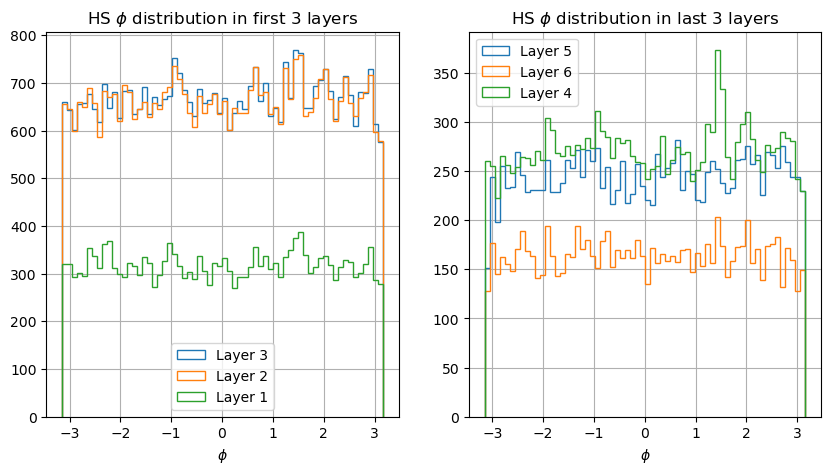

In [94]:
fig10,ax10 = plt.subplots(1,2)
fig10.set_figheight(5)
fig10.set_figwidth(10)

ax10[0].hist(hs_pos[hs_pos.layer_index == 2].phi_pos, bins = 64, label = "Layer 3", histtype = "step")
ax10[0].hist(hs_pos[hs_pos.layer_index == 1].phi_pos, bins = 64, label = "Layer 2", histtype = "step")
ax10[0].hist(hs_pos[hs_pos.layer_index == 0].phi_pos, bins = 64, label = "Layer 1", histtype = "step")
ax10[0].legend()
ax10[0].set_title("HS $\phi$ distribution in first 3 layers")
ax10[0].set_xlabel("$\phi$")
ax10[0].grid(which = "both")


ax10[1].hist(hs_pos[hs_pos.layer_index == 4].phi_pos, bins = 64, label = "Layer 5", histtype = "step")
ax10[1].hist(hs_pos[hs_pos.layer_index == 5].phi_pos, bins = 64, label = "Layer 6", histtype = "step")
ax10[1].hist(hs_pos[hs_pos.layer_index == 3].phi_pos, bins = 64, label = "Layer 4", histtype = "step")
ax10[1].legend()
ax10[1].set_title("HS $\phi$ distribution in last 3 layers")
ax10[1].set_xlabel("$\phi$")
ax10[1].grid(which = "both")

fig10.savefig("phi_distribution_hs.png")

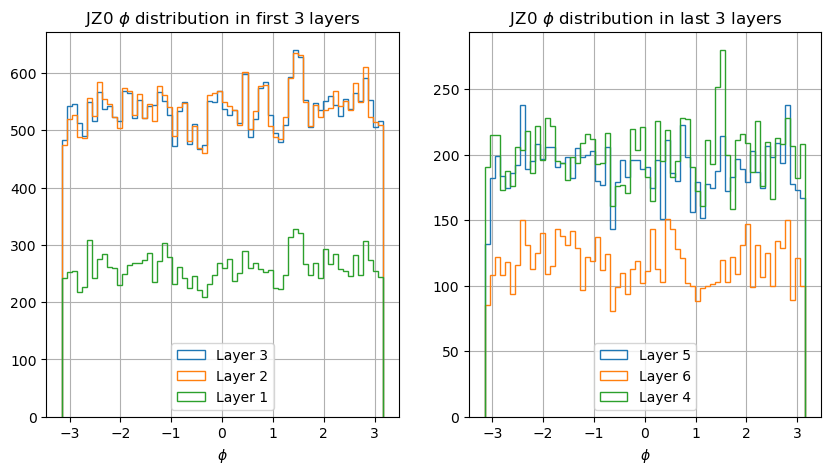

In [95]:
fig11,ax11 = plt.subplots(1,2)
fig11.set_figheight(5)
fig11.set_figwidth(10)

ax11[0].hist(jz0_pos[jz0_pos.layer_index == 2].phi_pos, bins = 64, label = "Layer 3", histtype = "step")
ax11[0].hist(jz0_pos[jz0_pos.layer_index == 1].phi_pos, bins = 64, label = "Layer 2", histtype = "step")
ax11[0].hist(jz0_pos[jz0_pos.layer_index == 0].phi_pos, bins = 64, label = "Layer 1", histtype = "step")
ax11[0].legend()
ax11[0].set_title("JZ0 $\phi$ distribution in first 3 layers")
ax11[0].set_xlabel("$\phi$")
ax11[0].grid(which = "both")


ax11[1].hist(jz0_pos[jz0_pos.layer_index == 4].phi_pos, bins = 64, label = "Layer 5", histtype = "step")
ax11[1].hist(jz0_pos[jz0_pos.layer_index == 5].phi_pos, bins = 64, label = "Layer 6", histtype = "step")
ax11[1].hist(jz0_pos[jz0_pos.layer_index == 3].phi_pos, bins = 64, label = "Layer 4", histtype = "step")
ax11[1].legend()
ax11[1].set_title("JZ0 $\phi$ distribution in last 3 layers")
ax11[1].set_xlabel("$\phi$")
ax11[1].grid(which = "both")

fig11.savefig("phi_distribution_jz0.png")

All events have similar distributions in $\phi$. Regular spikes in the frequency are observed at various angles. These spikes are observed in all layers.  The mean phi values are close to 0 for all events, in line with the expectation due to $\phi$ symmetry of the ATLAS detector.